# Simulazione Sistema a 2 Corpi

## Librerie

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import vettori2d as vec
from astropy.constants import G, au, M_sun

## Costanti utili

Definiamo le costanti necessarie per il programma:

In [84]:
N_steps = 5000
N_cycles = 5
Period = 1                                  # anni
Tau = N_cycles * Period / N_steps           # anni
year2sec = np.pi * 1e7                      # anni -> secondi

Se abbiamo scaricato astropy:

In [85]:
G_value = G.value                        # m^3 kg^-1 s^-2
M_body = M_sun.value                     # kg
AU_value = au.value                      # m
Conv = AU_value**-3 * year2sec**2        # riportiamo G_value nelle unità giuste

Altrimenti:

In [86]:
G_value = 6.6743e-11                      # m^3 kg^-1 s^-2
M_body = 1.988e30                         # kg
AU_value = 1.496e11                       # m
Conv = AU_value**-3 * year2sec**2         # riportiamo G_value nelle unità giuste

## Vettori Posizione e Velocità

Al fine di rendere l'implementazione dell'algoritmo di Verlet più versatile ragioneremo in termini di array  
bidimansionali, di dimensione $N_{body} \times N_{Steps}$.

$$
[\vec{r}] = \left(\begin{array}{cc} 
\vec{r}_1(0) & \vec{r}_1(\Delta t) & \vec{r}_1(2 \Delta t) & ... & \vec{r}_1(N\Delta t)\\
\vec{r}_2(0) & \vec{r}_2(\Delta t) & \vec{r}_2(2 \Delta t) & ... & \vec{r}_2(N\Delta t)
\end{array}\right)
$$ 

$$
[\vec{v}] = \left(\begin{array}{cc} 
\vec{v}_1(0) & \vec{v}_1(\Delta t) & \vec{v}_1(2 \Delta t) & ... & \vec{v}_1(N\Delta t)\\
\vec{v}_2(0) & \vec{v}_2(\Delta t) & \vec{v}_2(2 \Delta t) & ... & \vec{v}_2(N\Delta t)
\end{array}\right)
$$ 

In [87]:
positions = np.full((2, N_steps), fill_value=vec.vec2d())
velocities = np.full((2, N_steps), fill_value=vec.vec2d())

Questi due arrai sono l'equivalente delle matrici sopra ma rimepiti di vettori nulli.  

Definiamo delle condizioni iniziali e riempiamo il timestep zero degli array:

In [88]:
Pos0_1 = vec.vec2d(2,0)
Pos0_2 = vec.vec2d(-2,0)
Vel0_1 = vec.vec2d(0,1)
Vel0_2 = vec.vec2d(0,-1)

positions[:,0] = Pos0_1, Pos0_2
velocities[:,0] = Vel0_1, Vel0_2

## Funzione per Calcolare le Distanze

Al fine di calcolare le accelerazioni ci serve sapere quando sono lontani i due corpi ad ogni istante temporale, per fare ciò creiamo una funzione che prende in imput i vettori posizione dei due corpi ad un certo timestep e restituisce una matrice di distanze.  

Definita la distanza tra i corpi come:

$$
\vec{d_{12}} = \vec{r}_1 - \vec{r}_2
$$
$$
\vec{d_{21}} = \vec{r}_2 - \vec{r}_1
$$

La matrice sarà quindi del tipo:

$$
[\vec{d}] = \left(\begin{array}{cc} 
0 & \vec{d}_{12}\\
\vec{d}_{21} & 0 \\
\end{array}\right)
$$ 

Si nota che:

$$
\vec{d_{21}} = - \vec{d_{12}}
$$

Da cui:

$$
[\vec{d}] = \left(\begin{array}{cc} 
0 & \vec{d}_{12}\\
-\vec{d}_{12} & 0 \\
\end{array}\right)
$$ 

In [89]:
def GetDistances(positions):
    dist = np.full((2, 2), fill_value=vec.vec2d())

    for i in range(2):
        for j in range(i + 1, 2):

            dist[i, j] = positions[i] - positions[j]
            dist[j, i] = -dist[i, j]

    return dist

Usando in questo modo il doppio loop accediamo solamente agli elementi al di sopra della diagonale superiore. Qui elementi al di sotto vengono calcolati per simmetria.

## Funzione per Calcolare le Accelerazioni

Utilizziamo un approccio simile per definire una funzione che prenda in input la matrice delle distanze creata dalla funzione precedente e restituisca le accelerazioni totali a cui i due corpi sono soggetti.

Partiamo dalla forma della forza di gravità:

$$
\vec{F}_g = -G \cdot \frac{M \cdot m}{|\vec{d}|^2} \cdot \hat{d}
$$

Dove $\vec{d}$ è il vettore distanza tra i corpi considerati.  

Nel nostro caso le masse dei due corpi sono uguali, quindi possiamo scrivere le due accelerazioni come:

$$
\vec{A}_{12} = -G \cdot \frac{M}{|\vec{d}_{12}|^2} \cdot \hat{d}_{12}
$$
$$
\vec{A}_{21} = -G \cdot \frac{M}{|\vec{d}_{21}|^2} \cdot \hat{d}_{21}
$$

Gli indici indicano il corpo considerato e il corpo a cui è dovuta l'accelerazione: $\vec{A}_{12}$ corrisponde all'accelerazione del corpo 1 per effetto del corpo 2 e così via.  

Da cui la matrice delle accelerazioni:

$$
[\vec{A}] = \left(\begin{array}{cc} 
0 & \vec{A}_{12}\\
\vec{A}_{21} & 0 \\
\end{array}\right)
$$ 

Si nota che:

$$
\vec{A_{21}} = - \vec{A_{12}}
$$

Da cui:

$$
[\vec{A}] = \left(\begin{array}{cc} 
0 & \vec{A}_{12}\\
-\vec{A}_{12} & 0 \\
\end{array}\right)
$$

Dalla trattazione con due soli corpi non è troppo evidente, tuttavia l'accelerazione totale a cui è soggetto il corpo $i-esimo$ non è altro che la somma del valori lungo le righe di questa matrice. Proviamo a vederlo nel caso di N corpi:

$$
[\vec{A}] = \left(\begin{array}{cc} 
0 & \vec{A}_{12} & \vec{A}_{13} &...& \vec{A}_{1N}\\
\vec{A}_{21} & 0 & \vec{A}_{23} &...& \vec{A}_{2N}\\
. & . &  & & .\\
. &  & . & & .\\
. &  &  & . & .\\
\vec{A}_{N1} & \vec{A}_{N2} & \vec{A}_{N3} &...& 0\\
\end{array}\right)
$$ 


Sommando lungo le righe otteniamo:

$$
[\vec{A}] = \left(\begin{array}{cc} 
0 + \vec{A}_{12} + \vec{A}_{13} +...+ \vec{A}_{1N}\\
\vec{A}_{21} + 0 + \vec{A}_{23} +...+ \vec{A}_{2N}\\
. \\
. \\
. \\
\vec{A}_{N1} + \vec{A}_{N2} + \vec{A}_{N3} +...+ 0\\
\end{array}\right)
=
\left(\begin{array}{cc} 
\vec{A}_1\\
\vec{A}_2\\
. \\
. \\
. \\
\vec{A}_N\\
\end{array}\right)
$$


Che risulta essere proprio quello che ci serve!

In [90]:
def GetAccelerations(dist):

    acc = np.full((2, 2), fill_value=vec.vec2d())

    for i in range(2):
        for j in range(i + 1, 2):

            dist_ij = dist[i, j]
            acc[i, j] = -G_value * M_body * Conv / dist_ij.mod() ** 2 * dist_ij.unit()
            acc[j, i] = -acc[i, j]

    return np.sum(acc, axis=1)

Il comando "$axis=1$" dice a Numpy di sommare lungo le righe.

## Velocity-Verlet

Tutto quello che ci resta da fare è utilizzare l'algoritmo di Verlet per far evolvere il sistema. La potenza di Numpy sta nel fatto che possiamo fare operazioni tra matrici, per esempio calcoliamo le velocità nel modo:

$$
V_{new} = V_{old} + \frac{1}{2}\left( A_{old} + A_{new}\right) \cdot dt
$$

Che si traduce in:

$$
\left(\begin{array}{cc} 
\vec{v}_{1,new}  \\
\vec{v}_{2,new} \\
\end{array}\right)
=
\left(\begin{array}{cc} 
\vec{v}_{1,old}  \\
\vec{v}_{2,old} \\
\end{array}\right)
+
\frac{1}{2}\left[
\left(\begin{array}{cc} 
\vec{A}_{1,old}  \\
\vec{A}_{2,old} \\
\end{array}\right)
+
\left(\begin{array}{cc} 
\vec{A}_{1,new}  \\
\vec{A}_{2,new} \\
\end{array}\right)
\right] \cdot dt
$$

Per le posizioni vale lo stesso.

In [91]:
def DoVerlet(old_positions, old_velocities):
    old_distances = GetDistances(old_positions)
    old_accelerations = GetAccelerations(old_distances)

    new_positions = old_positions + old_velocities*Tau + 0.5*old_accelerations*Tau**2
    new_distances = GetDistances(new_positions)
    new_accelerations = GetAccelerations(new_distances)
    new_velocities = old_velocities + 0.5*(old_accelerations + new_accelerations)*Tau

    return new_positions, new_velocities

## Loop di Run della Simulazione

L'ultimo stepo consiste nel creare un loop per iterare l'algoritmo di Verlet  
per tutti gli step temporali:

In [92]:
for i in range(N_steps-1):

    positions[:,i+1], velocities[:,i+1] = DoVerlet(positions[:,i], velocities[:,i])

## Plotting

Plottiamo le orbite che abbiamo calcolato:

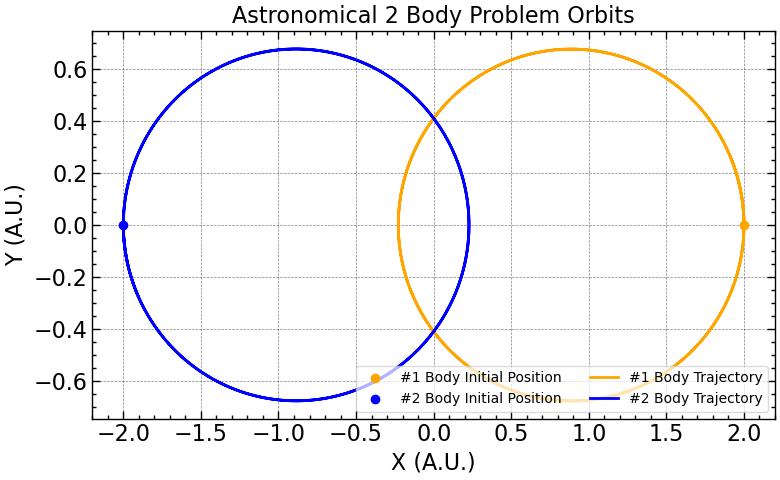

In [93]:
import scienceplots

# stile dei grafici
plt.style.use(['science', 'notebook', 'grid'])

# figura ed assi per il grafico delle traiettorie
fig, ax = plt.subplots(figsize=(8,5))

# scatter plot delle posizioni iniziali
ax.scatter(positions[0,0].x, positions[0,0].y, color='orange', label='#1 Body Initial Position')
ax.scatter(positions[1,0].x, positions[1,0].y, color='blue', label='#2 Body Initial Position')

# line plot delle traiettorie
ax.plot([positions[0,i].x for i in range(N_steps)], [positions[0,i].y for i in range(N_steps)], color='orange', label='#1 Body Trajectory')
ax.plot([positions[1,i].x for i in range(N_steps)], [positions[1,i].y for i in range(N_steps)], color='blue', label='#2 Body Trajectory')

# personalizzazione assi
ax.set_xlabel('X (A.U.)')
ax.set_ylabel('Y (A.U.)')
ax.set_title('Astronomical 2 Body Problem Orbits', fontsize=16)
ax.legend(fontsize=10, ncols=2, frameon=True, loc='lower right', framealpha=0.7)

fig.tight_layout()
plt.show()